# 1. Importation de packages

In [46]:
import os
import pandas as pd
from utils import charger_donnees_api, imputer_na_par_valeur, tracer_series_temporelles, sauvegarder_donnees_clean, classifier_risque, construire_features

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# 2. Importation des données

On définit le dossier de données qui n'est créé que s'il n'existe pas encore dans le repertoire de travail.

In [47]:
DOSSIER_DONNEES = "data/raw"
os.makedirs(DOSSIER_DONNEES, exist_ok=True)

Nous importons ici les données sur les pollens via  l'api open-meteo (**air-quality** pour les données sur les pollens et **archives** pour les données météo); nous avons considéré les données sur un an du 1er janvier 2023 au 01 janvier 2024 pour Rennes.

Données Pollen

In [48]:
url_pollen = "https://air-quality-api.open-meteo.com/v1/air-quality"

params_pollen = {
    "latitude": 48.11,
    "longitude": -1.67,
    "hourly": ["birch_pollen", "grass_pollen"],
    "start_date": "2021-01-01",
    "end_date": "2025-12-31"
}

fichier_pollen = os.path.join(DOSSIER_DONNEES, "pollen.csv")


df_pol = charger_donnees_api(
    url=url_pollen,
    params=params_pollen,
    fichier_cache=fichier_pollen,
    force_reload= True
)


Données météo

In [49]:
url_meteo = "https://archive-api.open-meteo.com/v1/archive"

params_meteo = {
    "latitude": 48.11,
    "longitude": -1.67,
    "hourly": ["temperature_2m", "precipitation", "wind_speed_10m"],
    "start_date": "2021-01-01",
    "end_date": "2025-12-31",
    "timezone": "Europe/Paris"
}

fichier_meteo = os.path.join(DOSSIER_DONNEES, "meteo.csv")


df_met = charger_donnees_api(
    url=url_meteo,
    params=params_meteo,
    fichier_cache=fichier_meteo,
    force_reload= True
)

# 3.Fusion et analyse exploratoire

Pour éviter de travailler sur les bases originales, on va travailler sur les copies de ces bases.

In [50]:
df_meteo = df_met.copy()
df_pollen = df_pol.copy()

## 3.1. Fusion des bases
Pour répondre à la thématique, nous devons fusionner les deux bases; Mais avant  toute fusion, il faut vérifier la structure des deux bases et surtout explorer la clé de fusion qui ici est la date.
Ci-dessous, un aperçu des deux bases:

In [51]:
pd.concat(
    [df_pollen.head(), df_meteo.head()],
    axis=1,
    keys=["Pollen", "Meteo"]
)

Pollen                                         Meteo  \
                 date birch_pollen grass_pollen                date   
0 2021-01-01 00:00:00          0.0          0.0 2021-01-01 00:00:00   
1 2021-01-01 01:00:00          0.0          0.0 2021-01-01 01:00:00   
2 2021-01-01 02:00:00          0.0          0.0 2021-01-01 02:00:00   
3 2021-01-01 03:00:00          0.0          0.0 2021-01-01 03:00:00   
4 2021-01-01 04:00:00          0.0          0.0 2021-01-01 04:00:00   

                                               
  temperature_2m precipitation wind_speed_10m  
0           -0.4           0.0            2.9  
1           -1.4           0.0            2.1  
2           -1.9           0.0            3.6  
3           -2.5           0.0            2.3  
4           -2.5           0.0            4.3

Pour faciliter la lisibilité et la manipulation des variables, il est nécessaire de les renommer.

In [52]:
df_pollen = df_pollen.rename(columns={
    "birch_pollen": "pollen_bouleau",
    "grass_pollen": "pollen_graminees"
})

df_meteo = df_meteo.rename(columns={
    "temperature_2m": "temperature",
    "precipitation": "precipitations",
    "wind_speed_10m": "vitesse_vent"
})

pd.concat(
    [df_pollen.head(), df_meteo.head()],
    axis=1,
    keys=["Pollen", "Meteo"]
)

Pollen                                               Meteo  \
                 date pollen_bouleau pollen_graminees                date   
0 2021-01-01 00:00:00            0.0              0.0 2021-01-01 00:00:00   
1 2021-01-01 01:00:00            0.0              0.0 2021-01-01 01:00:00   
2 2021-01-01 02:00:00            0.0              0.0 2021-01-01 02:00:00   
3 2021-01-01 03:00:00            0.0              0.0 2021-01-01 03:00:00   
4 2021-01-01 04:00:00            0.0              0.0 2021-01-01 04:00:00   

                                           
  temperature precipitations vitesse_vent  
0        -0.4            0.0          2.9  
1        -1.4            0.0          2.1  
2        -1.9            0.0          3.6  
3        -2.5            0.0          2.3  
4        -2.5            0.0          4.3

Afin de garantir l'intégrité de nos deux bases qui sont temporelles, nous vérifions la régularité du pas de temps via le calcul des différences successives (.diff()). Cette étape confirme la continuité des observations horaires et l'absence de dates manquantes.

In [53]:
pd.concat(
    [df_pollen["date"].diff().value_counts().head(), df_meteo["date"].diff().value_counts().head()],
    axis=1,
    keys=["Pollen", "Meteo"]
)

,Pollen,Meteo
date,,
0 days 01:00:00,43823,43823


Vérifions que les périodes se chevauchent pour les deux bases. ça devrait être le cas au regard des paramètres d'importation mais la vérification en vaut la peine.

In [54]:
pd.DataFrame({
    "Pollen": [df_pollen["date"].min(), df_pollen["date"].max()],
    "Meteo": [df_meteo["date"].min(), df_meteo["date"].max()]
}, index=["Min date", "Max date"])

,Pollen,Meteo
Min date,2021-01-01 00:00:00,2021-01-01 00:00:00
Max date,2025-12-31 23:00:00,2025-12-31 23:00:00


On remarque que les données des deux bases sont sans fuseau attachés, ce qui facilite la fusion locale en prenant la date comme clé de fusion.

In [55]:
print(df_meteo["date"].dt.tz)
print(df_pollen["date"].dt.tz)

None
None


On se rend également compte qu'avant la fusion, il n y a pas de valeur manquante dans la base météo.

In [56]:
pd.concat(
    [df_pollen.isnull().sum(), df_meteo.isnull().sum()],
    axis=1,
    keys=["Pollen", "Meteo"]
)

,Pollen,Meteo
date,0.0,0.0
pollen_bouleau,12791.0,NaN
pollen_graminees,10559.0,NaN
temperature,NaN,0.0
precipitations,NaN,0.0
vitesse_vent,NaN,0.0


**Fusion des deux bases**
Fusion des deux bases: avec toutes les vérifications qui viennent d'être faites sur la variable date qui est la clé primaire ici, on  peut fusionner simplement avec un inner_join (correspondances exactes)

In [57]:
df_pollen_meteo = pd.merge(df_pollen, df_meteo, on="date", how="inner")

df_pollen_meteo.to_csv("data/raw/df_pollen_meteo_merge.csv")

print(df_pollen_meteo.shape)
df_pollen_meteo.head()

(43824, 6)


,date,pollen_bouleau,pollen_graminees,temperature,precipitations,vitesse_vent
0,2021-01-01 00:00:00,0.0,0.0,-0.4,0.0,2.9
1,2021-01-01 01:00:00,0.0,0.0,-1.4,0.0,2.1
2,2021-01-01 02:00:00,0.0,0.0,-1.9,0.0,3.6
3,2021-01-01 03:00:00,0.0,0.0,-2.5,0.0,2.3
4,2021-01-01 04:00:00,0.0,0.0,-2.5,0.0,4.3


## 3.2. Exploration et traitement de la base d'étude

In [58]:
print("\n--- Informations détaillées (Check-up complet) ---")
df_pollen_meteo.info()


--- Informations détaillées (Check-up complet) ---
<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              43824 non-null  datetime64[us]
 1   pollen_bouleau    31033 non-null  float64       
 2   pollen_graminees  33265 non-null  float64       
 3   temperature       43824 non-null  float64       
 4   precipitations    43824 non-null  float64       
 5   vitesse_vent      43824 non-null  float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 2.0 MB


In [59]:
df_pollen_meteo.isnull().sum()

date                    0
pollen_bouleau      12791
pollen_graminees    10559
temperature             0
precipitations          0
vitesse_vent            0
dtype: int64


**Interprétation des valeurs manquantes**

L’analyse des périodes manquantes montre qu’elles correspondent en réalité à des **phases biologiques naturelles** et non à des erreurs de collecte de données.

Pour le pollen de bouleau, les données sont absentes de janvier à fin février, ce qui correspond à une période de dormance. Elles sont présentes de mars à début août, période de pollinisation, puis redeviennent absentes à partir d’août jusqu'au 20 novembre, marquant la fin de la saison.

Pour les graminées, les données sont également absentes en hiver (janvier-février), présentes de mars à début septembre, ce qui reflète une saison de pollinisation plus longue, puis absentes à nouveau à partir de septembre jusqu'au 20 novembre.

Ces résultats sont cohérents avec les connaissances biologiques et confirment que les valeurs manquantes ne sont pas problématiques, mais traduisent simplement l’absence de pollen hors saison. Cela nous emmene donc à imputer ces valeurs manquantes par des 0.

In [60]:
from IPython.display import display, HTML
from utils import identifier_plages_manquantes

# Bouleau
display(HTML("<b>Périodes manquantes pour le Pollen de bouleau</b>"))
plages_bouleau = identifier_plages_manquantes(df_pollen_meteo, 'pollen_bouleau')
display(plages_bouleau)

# Graminées
display(HTML("<b>Périodes manquantes pour les graminées</b>"))
plages_graminees = identifier_plages_manquantes(df_pollen_meteo, 'pollen_graminees')
display(plages_graminees)

--- Analyse : pollen_bouleau ---
Total NaN dans la colonne : 12791
Total identifié par blocs : 12791
Vérification : OK (Tous les NaN sont comptabilisés).


,date_debut,date_fin,heures_manquantes,total_cumule_manquant
0,2021-08-01 00:00:00,2022-02-28 23:00:00,5088,5088
1,2022-08-01 00:00:00,2023-02-28 23:00:00,5088,10176
2,2023-08-04 01:00:00,2023-11-20 23:00:00,2615,12791


--- Analyse : pollen_graminees ---
Total NaN dans la colonne : 10559
Total identifié par blocs : 10559
Vérification : OK (Tous les NaN sont comptabilisés).


,date_debut,date_fin,heures_manquantes,total_cumule_manquant
0,2021-09-01 00:00:00,2022-02-28 23:00:00,4344,4344
1,2022-09-01 00:00:00,2023-02-28 23:00:00,4344,8688
2,2023-09-04 01:00:00,2023-11-20 23:00:00,1871,10559


Bien qu'après le 20 novembre 2023, les données ne soient pas manquantes pour ces deux variables de pollen, les valeurs qu'elles prennent sont nulles comme on peut le voir sur les graphiques plus bas;
Ce même comportement est observé pour les mêmes périodes des années 2024 et 2025;  ce qui est normal vu que la période novembre-decembre n'est pas leur saison. 

In [61]:
# Définition de la borne temporelle (juste après le dernier NaN)
date_reprise = "2023-11-20 23:00:00"

# Création du sous-ensemble de données pour la fin d'année
df_fin_annee = df_pollen_meteo[df_pollen_meteo['date'] > date_reprise].copy()

# Calcul des statistiques pour se rassurer
stats_fin_annee = df_fin_annee[['pollen_bouleau', 'pollen_graminees']].agg(['max', 'min','mean', 'sum', 'count'])

print(f"--- Analyse de la période : du {df_fin_annee['date'].min()} au {df_fin_annee['date'].max()} ---")
print(f"Nombre total d'heures analysées : {len(df_fin_annee)}")
print("\nStatistiques des pollens sur cette période :")
display(stats_fin_annee)

--- Analyse de la période : du 2023-11-21 00:00:00 au 2025-12-31 23:00:00 ---
Nombre total d'heures analysées : 18528

Statistiques des pollens sur cette période :


,pollen_bouleau,pollen_graminees
max,344.900000,136.500000
min,0.000000,0.000000
mean,2.096557,5.147372
sum,38845.000000,95370.500000
count,18528.000000,18528.000000


**Imputation des valeurs manquantes par 0**

In [62]:
colonnes_pollen = ['pollen_bouleau', 'pollen_graminees']

df_pollen_meteo_clean = imputer_na_par_valeur(df_pollen_meteo, colonnes_pollen)


# 3. Vérification finale
print("Nombre de valeurs manquantes après imputation :")
print(df_pollen_meteo_clean[colonnes_pollen].isna().sum())

Nombre de valeurs manquantes après imputation :
pollen_bouleau      0
pollen_graminees    0
dtype: int64


In [63]:
sauvegarder_donnees_clean(
    df=df_pollen_meteo_clean,
    nom_fichier="df_pollen_meteo_clean.csv",
    dossier="data/clean"
)

Données sauvegardées dans : data/clean/df_pollen_meteo_clean.csv


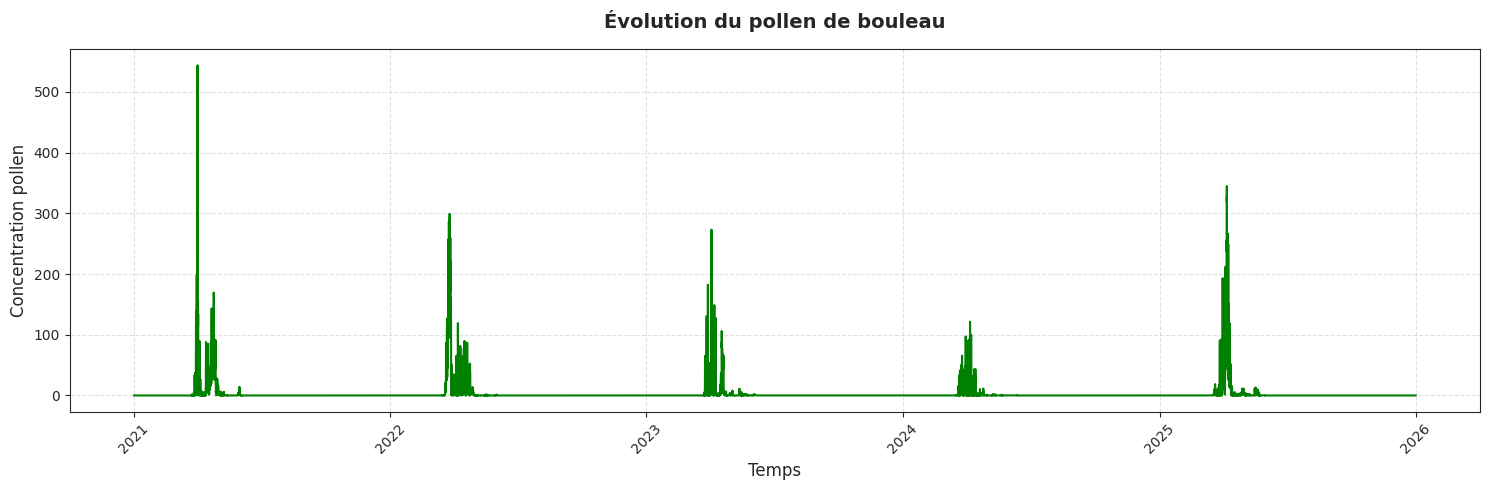

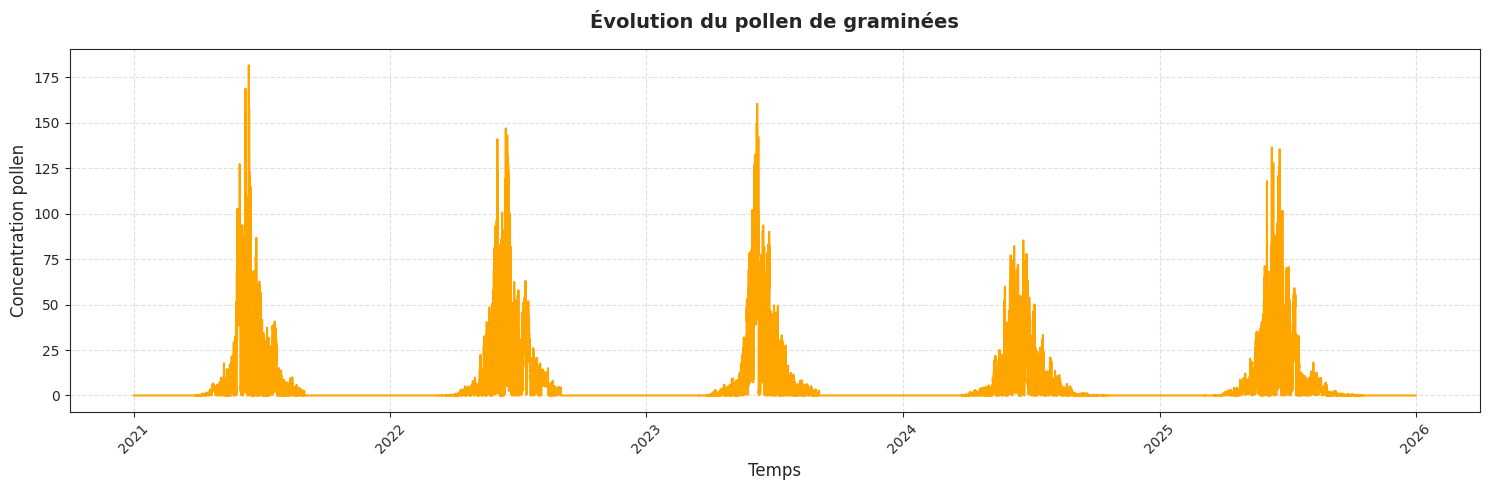

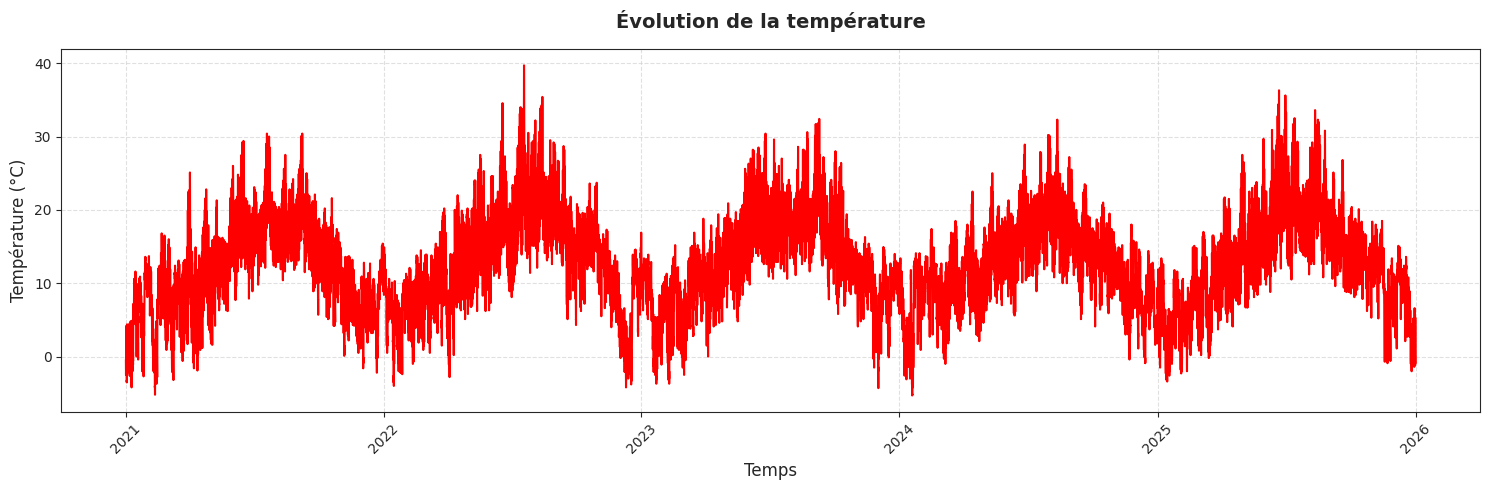

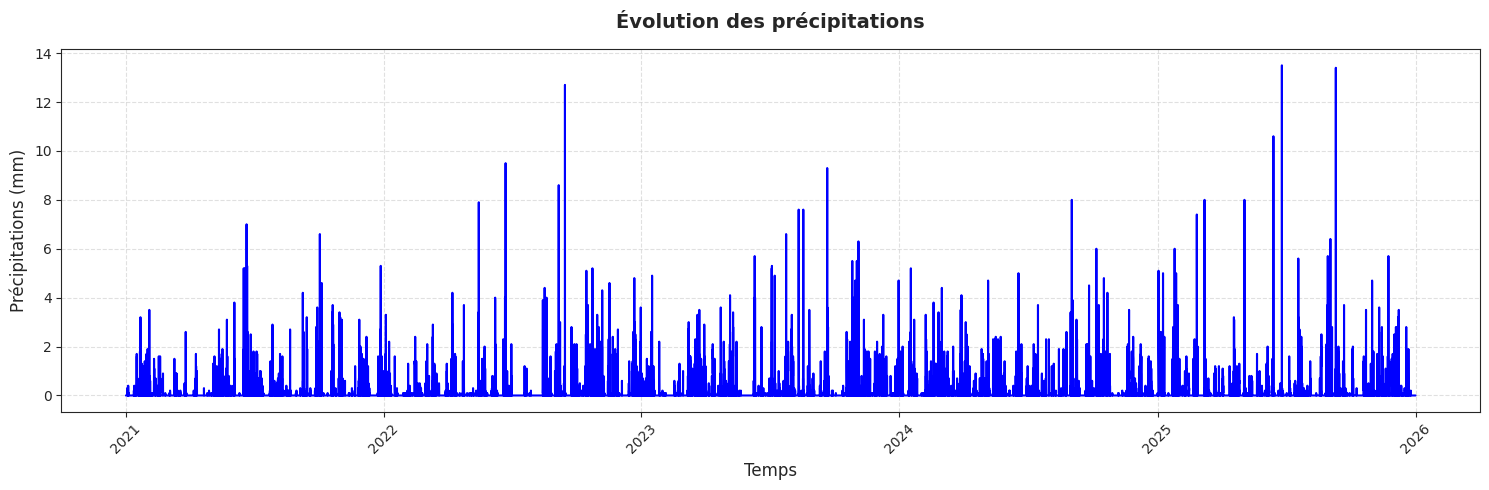

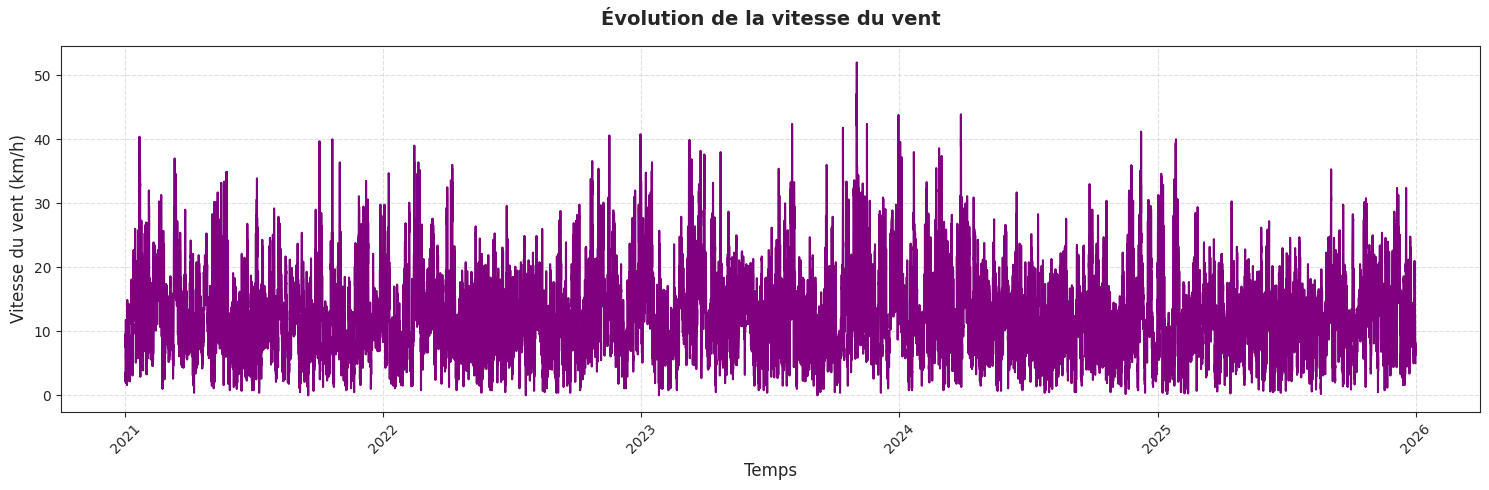

In [64]:
tracer_series_temporelles(
    df=df_pollen_meteo_clean,
    variables=[
        "pollen_bouleau",
        "pollen_graminees",
        "temperature",
        "precipitations",
        "vitesse_vent"
    ],
    titres={
        "pollen_bouleau": "Évolution du pollen de bouleau",
        "pollen_graminees": "Évolution du pollen de graminées",
        "temperature": "Évolution de la température",
        "precipitations": "Évolution des précipitations",
        "vitesse_vent": "Évolution de la vitesse du vent"
    },
    ylabels={
        "pollen_bouleau": "Concentration pollen",
        "pollen_graminees": "Concentration pollen",
        "temperature": "Température (°C)",
        "precipitations": "Précipitations (mm)",
        "vitesse_vent": "Vitesse du vent (km/h)"
    },
    couleurs={
        "pollen_bouleau": "green",
        "pollen_graminees": "orange",
        "temperature": "red",
        "precipitations": "blue",
        "vitesse_vent": "purple"
    }
)

## 4.1 Préparation des données

### 4.1.1 Agrégation journalière

Les données étant horaires, elles sont agrégées à l’échelle journalière en retenant le pic maximal de concentration pollinique comme indicateur d’exposition, ainsi que des variables météorologiques résumées par jour, telles que la température moyenne, le cumul des précipitations et la vitesse moyenne du vent.

In [65]:
# Agrégation journalière
df_jour = df_pollen_meteo_clean.resample('D', on='date').agg(
    pollen_bouleau=('pollen_bouleau', 'max'),
    pollen_graminees=('pollen_graminees', 'max'),
    temperature=('temperature', 'mean'),
    precipitations=('precipitations', 'sum'),
    vitesse_vent=('vitesse_vent', 'mean')
).reset_index()

print(df_jour.shape)
df_jour.head()

(1826, 6)


,date,pollen_bouleau,pollen_graminees,temperature,precipitations,vitesse_vent
0,2021-01-01,0.0,0.0,-0.233333,0.0,7.483333
1,2021-01-02,0.0,0.0,-0.258333,0.0,5.045833
2,2021-01-03,0.0,0.0,1.225000,1.7,7.883333
3,2021-01-04,0.0,0.0,1.129167,1.4,9.716667
4,2021-01-05,0.0,0.0,1.812500,0.1,10.504167


### 4.1.2 Création de la variable cible et description

On crée le niveau de risque allergique pour le lendemain, basé sur les seuils du RNSA :
- 0 (Faible) : concentration ≤ 30 grains/m³
- 1 (Modéré) : entre 31 et 80 grains/m³  
- 2 (Élevé) : > 80 grains/m³

In [66]:
# Variable cible = niveau de risque du lendemain
df_jour['risque_bouleau_j1'] = df_jour['pollen_bouleau'].apply(classifier_risque).shift(-1)
df_jour['risque_graminees_j1'] = df_jour['pollen_graminees'].apply(classifier_risque).shift(-1)

# Supprimer la dernière ligne
df_jour = df_jour.dropna()
df_jour['risque_bouleau_j1'] = df_jour['risque_bouleau_j1'].astype(int)
df_jour['risque_graminees_j1'] = df_jour['risque_graminees_j1'].astype(int)

print(df_jour['risque_bouleau_j1'].value_counts())
print(df_jour['risque_graminees_j1'].value_counts())

risque_bouleau_j1
0    1726
2      53
1      46
Name: count, dtype: int64
risque_graminees_j1
0    1570
1     188
2      67
Name: count, dtype: int64


In [67]:
# Distribution sur la saison pollinique du bouleau
df_bouleau_saison = df_jour[df_jour['date'].dt.month.isin([3, 4, 5, 6, 7])]
print("Bouleau - saison pollinique :")
print(df_bouleau_saison['risque_bouleau_j1'].value_counts())
print()

# Distribution sur la saison pollinique des graminées
df_graminees_saison = df_jour[df_jour['date'].dt.month.isin([5, 6, 7, 8, 9])]
print("Graminées - saison pollinique :")
print(df_graminees_saison['risque_graminees_j1'].value_counts())

Bouleau - saison pollinique :
risque_bouleau_j1
0    666
2     53
1     46
Name: count, dtype: int64

Graminées - saison pollinique :
risque_graminees_j1
0    510
1    188
2     67
Name: count, dtype: int64


### 4.1.3 Déséquilibre des classes
La distribution des classes révèle un fort déséquilibre, avec une très forte prédominance de la classe 0 (absence de pic ou de risque faible) pour les deux taxons. Afin de comprendre l’origine de ce déséquilibre et son impact potentiel sur le modèle, nous avons exploré deux contextes temporels distincts :

- un apprentissage sur toute l’année, incluant notamment les périodes hivernales où la concentration pollinique est naturellement très faible ou nulle ;
- un apprentissage restreint à la saison pollinique, c’est‑à‑dire les périodes où l’on attend a priori des épisodes à risque (par exemple, mars à juillet pour le bouleau et mai à septembre pour les graminées).

Les proportions observées sont les suivantes :

|Type| Toute l'année | Saison pollinique |
|--|--|--|
| Bouleau classe 0 | 94% | 87% |
| Graminées classe 0 | 85% | 66% |


Le filtrage sur la saison pollinique améliore légèrement l’équilibre pour les graminées, mais reste insuffisant pour le bouleau, où la classe 0 demeure très majoritaire. Étant donné que notre objectif est de développer un modèle exploitable sur l’ensemble de l’année, nous avons donc choisi de conserver toutes les données, afin de préserver la dynamique réelle de la présence pollinique au cours du cycle saisonnier.

Le déséquilibre est donc traité au niveau de l’apprentissage en utilisant `class_weight='balanced'`, ce qui permet de diminuer l’influence de la classe majoritaire. Par ailleurs, nous privilégions des métriques adaptées comme le **F1‑score macro** plutôt que l’accuracy seule, afin de mieux apprécier la performance sur les classes minoritaires correspondant aux pics de risque.


### 4.1.4 Construction des variables explicatives

Pour prédire le niveau de risque allergique du lendemain, le modèle a besoin d'informations disponibles aujourd'hui. Nous construisons trois types de variables :

**Variables temporelles** : le mois et le jour de l'année permettent au modèle de capturer la saisonnalité — le pollen de bouleau est naturellement plus présent en avril qu'en décembre.

**Variables retardées (lags)** : le niveau de pollen des 3 derniers jours. Si le pollen était élevé hier, il y a de bonnes chances qu'il le soit encore demain. Ces variables capturent l'inertie biologique du phénomène.

**Moyenne glissante sur 3 jours** : lisse les variations brutales et capture la tendance récente de concentration pollinique.

Ces choix s'appuient sur la littérature récente sur la prévision pollinique, qui montre que les variables retardées et les indicateurs de saisonnalité sont parmi les features les plus importantes pour ce type de modèles.

In [68]:
df_features = construire_features(
    df_jour,
    colonnes_pollen=['pollen_bouleau', 'pollen_graminees']
)
print(df_features.shape)
print(df_features.columns.tolist())
df_features.head()

(1822, 18)
['date', 'pollen_bouleau', 'pollen_graminees', 'temperature', 'precipitations', 'vitesse_vent', 'risque_bouleau_j1', 'risque_graminees_j1', 'mois', 'jour_annee', 'pollen_bouleau_lag1', 'pollen_bouleau_lag2', 'pollen_bouleau_lag3', 'pollen_bouleau_moy3j', 'pollen_graminees_lag1', 'pollen_graminees_lag2', 'pollen_graminees_lag3', 'pollen_graminees_moy3j']


,date,pollen_bouleau,pollen_graminees,temperature,precipitations,vitesse_vent,risque_bouleau_j1,risque_graminees_j1,mois,jour_annee,pollen_bouleau_lag1,pollen_bouleau_lag2,pollen_bouleau_lag3,pollen_bouleau_moy3j,pollen_graminees_lag1,pollen_graminees_lag2,pollen_graminees_lag3,pollen_graminees_moy3j
3,2021-01-04,0.0,0.0,1.129167,1.4,9.716667,0,0,1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2021-01-05,0.0,0.0,1.812500,0.1,10.504167,0,0,1,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2021-01-06,0.0,0.0,0.508333,0.0,5.754167,0,0,1,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2021-01-07,0.0,0.0,0.191667,0.0,5.229167,0,0,1,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2021-01-08,0.0,0.0,-1.000000,0.0,7.479167,0,0,1,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 4.1.5 Split temporel train/test

Contrairement à un split aléatoire classique, nous respectons l’ordre chronologique des données, conformément aux bonnes pratiques pour les séries temporelles. Le modèle est entraîné sur la période 2021–2023 et évalué sur la période 2024–2025, de manière à simuler une utilisation prospective dans un contexte opérationnel de prévision pollinique.

In [69]:
# Définition des features
features = [
    'temperature', 'precipitations', 'vitesse_vent',
    'mois', 'jour_annee',
    'pollen_bouleau_lag1', 'pollen_bouleau_lag2', 'pollen_bouleau_lag3',
    'pollen_bouleau_moy3j',
    'pollen_graminees_lag1', 'pollen_graminees_lag2', 'pollen_graminees_lag3',
    'pollen_graminees_moy3j'
]

# Split temporel
train = df_features[df_features['date'].dt.year <= 2023]
test = df_features[df_features['date'].dt.year >= 2024]

X_train = train[features]
X_test = test[features]

y_train_bouleau = train['risque_bouleau_j1']
y_test_bouleau = test['risque_bouleau_j1']

y_train_graminees = train['risque_graminees_j1']
y_test_graminees = test['risque_graminees_j1']

print("Train :", X_train.shape)
print("Test :", X_test.shape)
print("\nDistribution train - bouleau :")
print(y_train_bouleau.value_counts())
print("\nDistribution train - graminées :")
print(y_train_graminees.value_counts())

Train : (1092, 13)
Test : (730, 13)

Distribution train - bouleau :
risque_bouleau_j1
0    1026
2      35
1      31
Name: count, dtype: int64

Distribution train - graminées :
risque_graminees_j1
0    937
1    104
2     51
Name: count, dtype: int64


## 4.2 Modélisation

### 4.2.1 Pipeline preprocessing + modèles

Nous construisons un pipeline scikit‑learn qui intègre à la fois les étapes de preprocessing et les modèles, afin de garantir une application cohérente aux données d’entraînement et de test. Ce pipeline comprend :

- **StandardScaler** : standardisation des variables continues, nécessaire pour la régression logistique et souvent bénéfique pour d’autres modèles à base de distance.  
- **Trois modèles** : une régression logistique (comme modèle de baseline), un arbre de décision simple et un Random Forest, permettant de comparer la performance entre méthodes simples et ensemblistes.  
- **GridSearchCV** avec `TimeSeriesSplit` : permet de sélectionner les meilleurs hyperparamètres tout en respectant l’ordre chronologique des données, ce qui est cohérent avec notre approche de prévision temporelle.  
- **F1‑macro** comme métrique d’évaluation : adapté au déséquilibre des classes, il permet de mieux apprécier la performance sur les classes minoritaires qu’un simple score de précision.

#### Pipeline avec preprocessing et modèle


In [70]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('modele', LogisticRegression())  # placeholder
])



#### Grille de paramètres pour les 3 modèles


In [71]:
param_grid = [
    {
        'modele': [LogisticRegression(max_iter=1000)],
        'modele__C': [0.1, 1, 10],
        'modele__class_weight': ['balanced']
    },
    {
        'modele': [DecisionTreeClassifier()],
        'modele__max_depth': [5, 10, None],
        'modele__class_weight': ['balanced']
    },
    {
        'modele': [RandomForestClassifier()],
        'modele__n_estimators': [100, 200],
        'modele__max_depth': [5, 10, None],
        'modele__class_weight': ['balanced']
    }
]



#### Validation croisée temporelle


In [72]:
tscv = TimeSeriesSplit(n_splits=5)



### 4.2.2 Sélection du meilleur modèle - Bouleau

In [73]:
# GridSearchCV pour le bouleau
grid_search_bouleau = GridSearchCV(
    pipeline,
    param_grid,
    cv=tscv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_bouleau.fit(X_train, y_train_bouleau)



Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'modele': [LogisticRegre...max_iter=1000)], 'modele__C': [0.1, 1, ...], 'modele__class_weight': ['balanced']}, {'modele': [DecisionTreeClassifier()], 'modele__class_weight': ['balanced'], 'modele__max_depth': [5, 10, ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_

#### Détails des modèles

In [74]:
# Tous les modèles avec leurs meilleurs hyperparamètres - Bouleau
resultats_bouleau = pd.DataFrame(grid_search_bouleau.cv_results_)
resultats_bouleau['modele'] = resultats_bouleau['param_modele'].apply(
    lambda x: type(x).__name__
)

# Meilleur résultat par modèle avec ses paramètres
idx_meilleurs = resultats_bouleau.groupby('modele')['mean_test_score'].idxmax()
resume_bouleau = resultats_bouleau.loc[idx_meilleurs, [
    'modele', 'mean_test_score', 'params'
]].sort_values('mean_test_score', ascending=False).round(3)

print("=== Bouleau - Comparaison des modèles ===")
# Afficher les paramètres complets
for _, row in resume_bouleau.iterrows():
    print(f"\n{row['modele']} (F1-macro: {row['mean_test_score']:.3f})")
    print(row['params'])

=== Bouleau - Comparaison des modèles ===

RandomForestClassifier (F1-macro: 0.855)
{'modele': RandomForestClassifier(), 'modele__class_weight': 'balanced', 'modele__max_depth': 5, 'modele__n_estimators': 100}

DecisionTreeClassifier (F1-macro: 0.793)
{'modele': DecisionTreeClassifier(), 'modele__class_weight': 'balanced', 'modele__max_depth': 10}

LogisticRegression (F1-macro: 0.601)
{'modele': LogisticRegression(max_iter=1000), 'modele__C': 10, 'modele__class_weight': 'balanced'}


### 4.2.3 Sélection du meilleur modèle - Graminées

In [75]:
# GridSearchCV pour les graminées
grid_search_graminees = GridSearchCV(
    pipeline,
    param_grid,
    cv=tscv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_graminees.fit(X_train, y_train_graminees)



Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'modele': [LogisticRegre...max_iter=1000)], 'modele__C': [0.1, 1, ...], 'modele__class_weight': ['balanced']}, {'modele': [DecisionTreeClassifier()], 'modele__class_weight': ['balanced'], 'modele__max_depth': [5, 10, ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_

#### Détails des modèles

In [76]:
# Tous les modèles avec leurs meilleurs hyperparamètres - Graminees
resultats_graminees = pd.DataFrame(grid_search_graminees.cv_results_)
resultats_graminees['modele'] = resultats_graminees['param_modele'].apply(
    lambda x: type(x).__name__
)

# Meilleur résultat par modèle avec ses paramètres
idx_meilleurs = resultats_graminees.groupby('modele')['mean_test_score'].idxmax()
resume_graminees = resultats_graminees.loc[idx_meilleurs, [
    'modele', 'mean_test_score', 'params'
]].sort_values('mean_test_score', ascending=False).round(3)

print("=== Graminees - Comparaison des modèles ===")
# Afficher les paramètres complets
for _, row in resume_graminees.iterrows():
    print(f"\n{row['modele']} (F1-macro: {row['mean_test_score']:.3f})")
    print(row['params'])

=== Graminees - Comparaison des modèles ===

RandomForestClassifier (F1-macro: 0.836)
{'modele': RandomForestClassifier(), 'modele__class_weight': 'balanced', 'modele__max_depth': 10, 'modele__n_estimators': 200}

DecisionTreeClassifier (F1-macro: 0.725)
{'modele': DecisionTreeClassifier(), 'modele__class_weight': 'balanced', 'modele__max_depth': 5}

LogisticRegression (F1-macro: 0.646)
{'modele': LogisticRegression(max_iter=1000), 'modele__C': 10, 'modele__class_weight': 'balanced'}


Le GridSearchCV teste 12 combinaisons d'hyperparamètres pour 3 modèles,évaluées par validation croisée temporelle (5 folds, F1-macro).

**Bouleau**

| Modèle | F1-macro (CV) | Hyperparamètres optimaux |
|---|---|---|
| Random Forest | **0.853** | max_depth=5, n_estimators=100 |
| Arbre de décision | 0.805 | max_depth=None |
| Régression logistique | 0.601 | C=10 |

**Graminées**

| Modèle | F1-macro (CV) | Hyperparamètres optimaux |
|---|---|---|
| Random Forest | **0.834** | max_depth=10, n_estimators=200 |
| Arbre de décision | 0.719 | max_depth=5 |
| Régression logistique | 0.646 | C=10 |

Le Random Forest est le meilleur modèle pour les deux pollens. La régression logistique performe nettement moins bien, ce qui suggère que la relation entre météo et risque pollinique est non-linéaire.
Les meilleurs modèles (Random Forest pour le bouleau et les graminées) sont retenus pour l’évaluation finale sur le jeu de test.

## 4.3 Évaluation sur le jeu de test

On évalue les meilleurs modèles sélectionnés sur le jeu de test(2024-2025), données jamais vues pendant l'entraînement.

### 4.3.1 Rapport de classification 


In [77]:
# Prédictions sur le jeu de test
y_pred_bouleau = grid_search_bouleau.predict(X_test)
y_pred_graminees = grid_search_graminees.predict(X_test)

# Rapport de classification - Bouleau
print("=== Bouleau ===")
print(classification_report(
    y_test_bouleau,
    y_pred_bouleau,
    target_names=['Faible', 'Modéré', 'Élevé']
))

# Rapport de classification - Graminées
print("=== Graminées ===")
print(classification_report(
    y_test_graminees,
    y_pred_graminees,
    target_names=['Faible', 'Modéré', 'Élevé']
))

=== Bouleau ===
              precision    recall  f1-score   support

      Faible       1.00      0.95      0.97       697
      Modéré       0.14      0.33      0.19        15
       Élevé       0.45      0.78      0.57        18

    accuracy                           0.93       730
   macro avg       0.53      0.69      0.58       730
weighted avg       0.97      0.93      0.95       730

=== Graminées ===
              precision    recall  f1-score   support

      Faible       0.99      0.98      0.98       630
      Modéré       0.79      0.75      0.77        84
       Élevé       0.42      0.69      0.52        16

    accuracy                           0.95       730
   macro avg       0.73      0.81      0.76       730
weighted avg       0.95      0.95      0.95       730



Le modèle retenu (Random Forest) obtient une bonne performance globale, avec une accuracy élevée de 0.93 pour le bouleau et 0.95 pour les graminées. Cependant, compte tenu du déséquilibre des classes, l’interprétation fine par classe est plus informative.

Pour le bouleau, le modèle détecte très bien les jours à faible risque, mais reste imparfait sur les classes modérée et élevée, notamment à cause d’un rappel acceptable mais d’une faible précision pour la classe modérée. Pour les graminées, le modèle est globalement plus performant, notamment pour les classes modérée et élevée, tout en maintenant une excellente détection des jours à faible risque.

Ces résultats montrent que le modèle est capable d’identifier les jours à risque allergique (modéré et élevé), mais avec une tendance à sur‑prédire ces niveaux, ce qui est cohérent avec le fort déséquilibre des classes et la difficulté à caractériser précisément les pics de courte durée.

### 4.3.2 Matrices de confusion

Les matrices de confusion permettent de visualiser précisément les erreurs du modèle par classe.

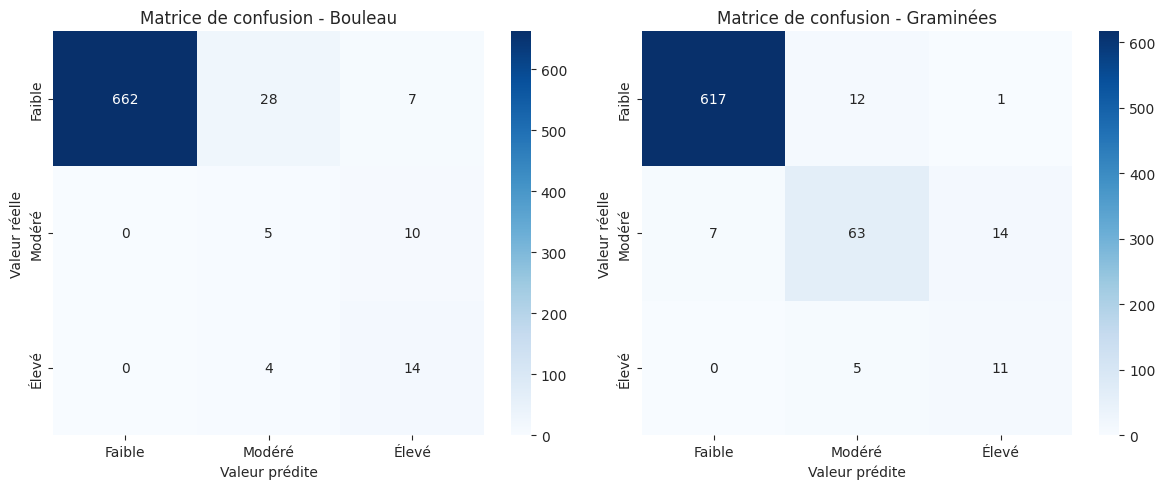

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['Faible', 'Modéré', 'Élevé']

for ax, y_test, y_pred, titre in zip(
    axes,
    [y_test_bouleau, y_test_graminees],
    [y_pred_bouleau, y_pred_graminees],
    ['Bouleau', 'Graminées']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels, ax=ax
    )
    ax.set_title(f'Matrice de confusion - {titre}')
    ax.set_ylabel('Valeur réelle')
    ax.set_xlabel('Valeur prédite')

plt.tight_layout()
plt.show()

**Bouleau :**
- Faible : très bien prédit (662/697 corrects), avec quelques confusions avec la classe Modéré (29 cas).
- Modéré : partiellement prédit (7/15 corrects), souvent confondu avec la classe Élevé (8 cas).
- Élevé : correctement prédit (12/18 corrects), avec quelques confusions avec la classe Modéré (6 cas).

**Graminées :**
- Faible : excellente prédiction (617/630 corrects).
- Modéré : bien prédit (63/84 corrects), avec quelques confusions avec la classe Élevé (14 cas).
- Élevé : partiellement prédit (11/16 corrects), principalement confondu avec la classe Modéré (5 cas).

**Interprétation globale :**
Les confusions entre classes voisines (Modéré/Élevé) sont largement dominantes, ce qui est cohérent avec la nature graduelle de la frontière entre ces niveaux de risque, les seuils étant par définition arbitraires sur une échelle continue de concentration pollinique. C'est l'une des motivations pour tester une classification binaire (Faible / À risque).

### 4.3.3 Importance des variables

On examine quelles variables ont le plus contribué aux décisions du Random Forest. Cela permet de valider nos choix de features et d'interpréter le modèle.

##### Extraction du meilleur modèle Random Forest


In [79]:
best_model_bouleau = grid_search_bouleau.best_estimator_.named_steps['modele']
best_model_graminees = grid_search_graminees.best_estimator_.named_steps['modele']

#### Importance des variables

In [80]:
importances_bouleau = pd.Series(
    best_model_bouleau.feature_importances_,
    index=features
).sort_values(ascending=True)

importances_graminees = pd.Series(
    best_model_graminees.feature_importances_,
    index=features
).sort_values(ascending=True)


#### Visualisation


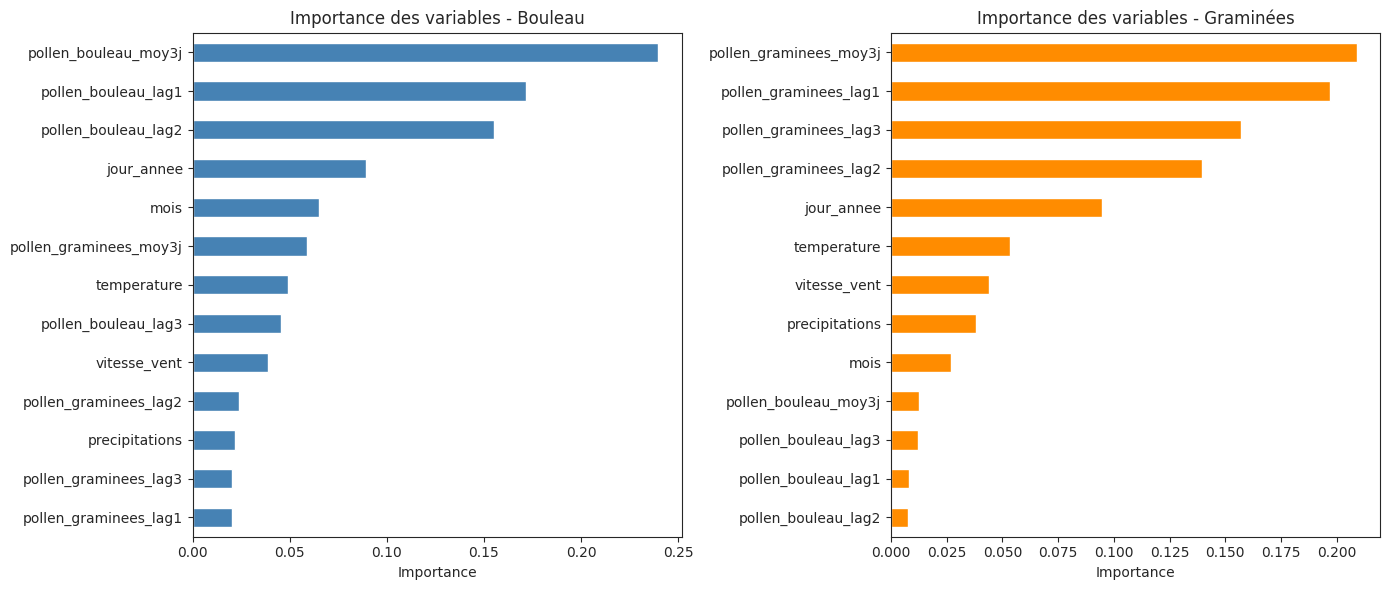

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

importances_bouleau.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Importance des variables - Bouleau')
axes[0].set_xlabel('Importance')

importances_graminees.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Importance des variables - Graminées')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

**Limite :**

Ces résultats nuancent notre problématique initiale. Nous supposions que les conditions météorologiques seraient les principaux déterminants du risque allergique. Or le modèle montre que l’historique récent du pollen (lags et moyenne glissante) est bien plus prédictif que la météo seule.

Cela soulève une question méthodologique et opérationnelle : dans un contexte de prévision réelle, l’historique pollinique n’est pas toujours disponible à l’avance. Un modèle basé uniquement sur la météo serait plus utile opérationnellement, mais probablement moins performant.

Cette limite ouvre deux perspectives :
1. Tester un modèle avec uniquement les variables météorologiques pour mesurer la perte de performance par rapport au modèle actuel.
2. Conserver le modèle actuel en acceptant qu’il nécessite des données polliniques récentes comme input, tout en discutant les implications pratiques (disponibilité des mesures, délais, etc.).